In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

For the amplitude of a heterodyne signal we can write

$$A \propto R_{\text{PD}}\sqrt{\eta_{\text{het}}P_1P_{\text{REF}}}.$$

Now, lets fix $P_{\text{REF}} = 250 \, \text{mW}$.

In [105]:
N = 5000

P_ref = 10e-3

P_0 = np.logspace(-5, 0, N)
R = 0.7      # photodiode responsivity [A/W]
het_eff = 0.9   # heterodyne efficiency (overlap of beams, mode-matching, etc.)

f = np.logspace(-4, 0, N)   # 0.1 mHz → 1 Hz
m = 0.53  # modulation index (for optimal power in the first sideband)

In [106]:
I_signal_BN = R * np.sqrt(2*P_0 * P_ref * het_eff)

In [107]:
def shot_noise(P_0, P_ref, R):
    return np.sqrt(2 * (P_0 + P_ref) * R * 1.6e-19)

def RIN_noise(P_0, P_ref, R, RIN):
    return RIN * R * np.sqrt(P_0**2 + P_ref**2)

def electronic_noise(el):
    return el

In [108]:
""" Total readout noise """
I_sn = shot_noise(P_0, P_ref, R)   # [A/√Hz]
phi_sn = I_sn / I_signal_BN  # [rad/√Hz]

RIN = 1e-7
I_RIN = RIN_noise(P_0, P_ref, R, RIN)   # [A/√Hz]
phi_RIN = I_RIN / I_signal_BN  # [rad/√Hz]

el = 1e-8
I_el = electronic_noise(el)   # [A/√Hz]
phi_el = I_el / I_signal_BN  # [rad/√Hz]


phi_total = np.sqrt(phi_RIN**2 + phi_sn**2 + phi_el**2) 
phi_total_SB = np.sqrt(phi_RIN**2 + phi_sn**2 + phi_el**2) / jv(1, m)**2 


In [109]:
""" Optimal local laser power """
idx_opt = np.argmin(phi_total_SB)
P_opt = P_0[idx_opt]
phi_opt = phi_total_SB[idx_opt]

print(f"Optimal local laser power: {P_opt*1e3:.2f} mW")
print(f"Minimum total phase noise: {phi_opt:.2e} rad/√Hz")

Optimal local laser power: 143.16 mW
Minimum total phase noise: 6.10e-06 rad/√Hz


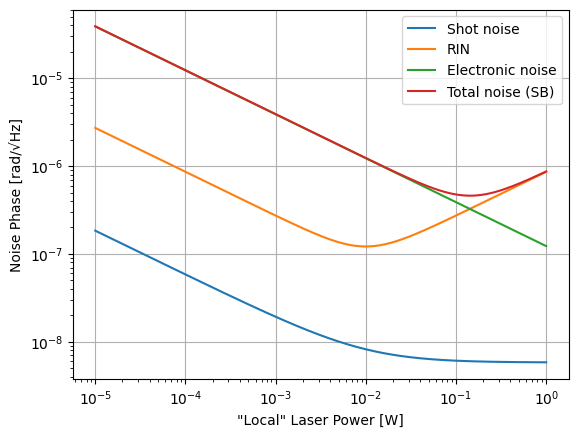

In [110]:
plt.plot(P_0, phi_sn /jv(0, m)**2 , label='Shot noise')
plt.plot(P_0, phi_RIN /jv(0, m)**2 , label='RIN')
plt.plot(P_0, phi_el /jv(0, m)**2 , label='Electronic noise')
#plt.plot(P_0, phi_total, label='Total noise')
plt.plot(P_0, phi_total /jv(0, m)**2 , label='Total noise (SB)')
#plt.vlines(P_ref, 1e-9, 1e-3, colors='k', linestyles='dotted')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.xlabel('"Local" Laser Power [W]')
plt.ylabel('Noise Phase [rad/√Hz]')
plt.legend()
plt.savefig("power_vs_noise.pdf")

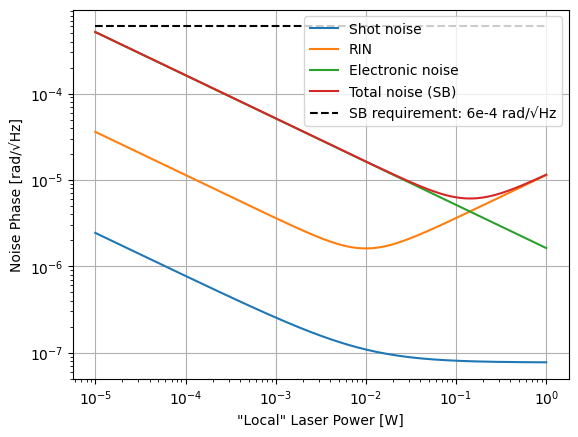

In [111]:
plt.plot(P_0, phi_sn/ jv(1, m)**2 , label='Shot noise')
plt.plot(P_0, phi_RIN/ jv(1, m)**2 , label='RIN')
plt.plot(P_0, phi_el/ jv(1, m)**2 , label='Electronic noise')
#plt.plot(P_0, phi_total, label='Total noise')
plt.plot(P_0, phi_total_SB, label='Total noise (SB)')
plt.hlines(6e-4, P_0[0], P_0[-1], colors='k', linestyles='dashed', label='SB requirement: 6e-4 rad/√Hz')
#plt.vlines(P_ref, 1e-9, 1e-3, colors='k', linestyles='dotted')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.xlabel('"Local" Laser Power [W]')
plt.ylabel('Noise Phase [rad/√Hz]')
plt.legend()
plt.savefig("SB_power_vs_noise.pdf")

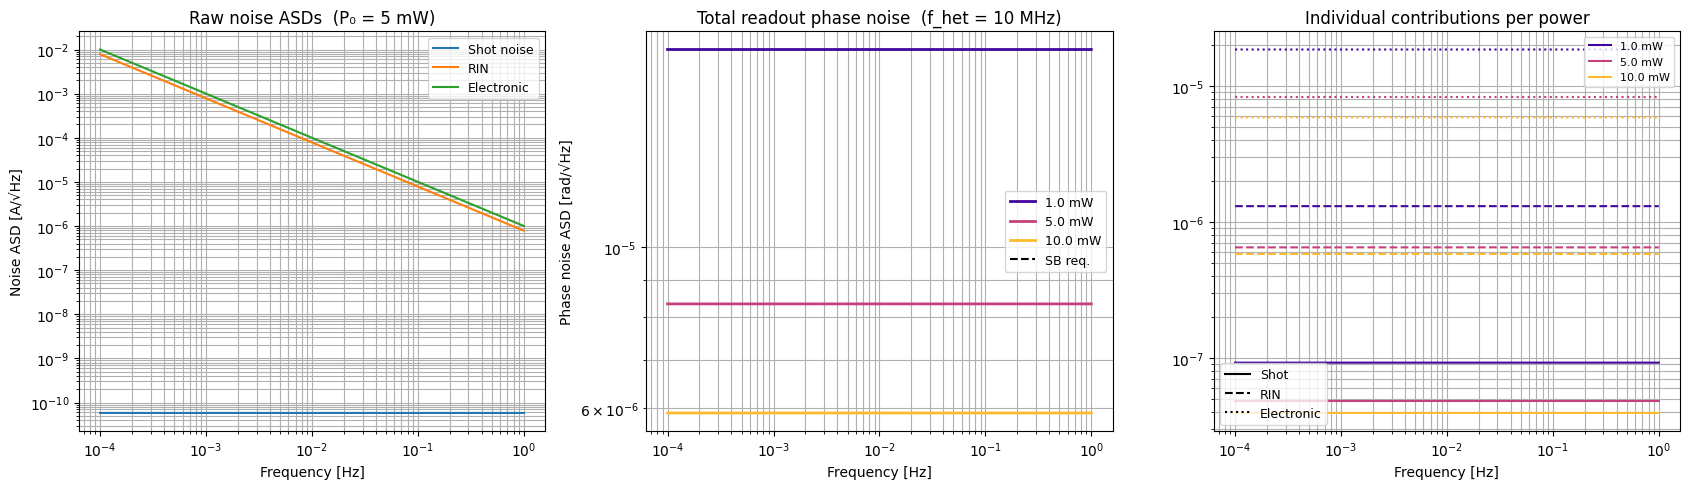

In [121]:
""" Readout noise ASD vs frequency — fixed powers, frequency-dependent noise models

Colored noise formula from phasemeter mixing (see notes):
    phi_tilde(f) = sqrt( S_n(f_het+f)^2 + S_n(f_het-f)^2 ) / A_signal

For f_het >> f_meas this reduces to sqrt(2)*S_n(f_het)/A — flat in the measurement band.
"""

f_het = 10e6          # heterodyne / sideband carrier frequency [Hz]
f_meas = np.logspace(-4, 0, N)   # measurement band: 0.1 mHz → 1 Hz

# --- Frequency-dependent noise ASD models [A/√Hz] ---

def S_shot_f(f_eval, P_0, P_ref, R):
    """Shot noise — white"""
    return np.sqrt(2 * 1.6e-19 * R * (P_0 + P_ref)) * np.ones_like(f_eval)

def S_RIN_f(f_eval, P_0, P_ref, R, RIN_floor, f_knee=1e3):
    """RIN with 1/f knee below f_knee [Hz]"""
    rin_f = RIN_floor * np.sqrt(1 + (f_knee / np.abs(f_eval))**2)
    return R * np.sqrt(P_0**2 + P_ref**2) * rin_f

def S_el_f(f_eval, el_floor, f_knee=100.0):
    """Electronic noise with 1/f knee below f_knee [Hz]"""
    return el_floor * np.sqrt(1 + (f_knee / np.abs(f_eval))**2)

# --- Phase noise ASD via colored noise formula ---

def phase_noise_asd(f_meas, f_het, P_0, P_ref, R, het_eff, RIN, el, m):
    A = R * np.sqrt(2 * P_0 * P_ref * het_eff) * jv(1, m)   # sideband signal RMS [A]
    fp, fm = f_het + f_meas, f_het - f_meas
    sn   = np.sqrt(S_shot_f(fp, P_0, P_ref, R)**2 + S_shot_f(fm, P_0, P_ref, R)**2) / A
    rin  = np.sqrt(S_RIN_f( fp, P_0, P_ref, R, RIN)**2 + S_RIN_f( fm, P_0, P_ref, R, RIN)**2) / A
    elec = np.sqrt(S_el_f(  fp, el)**2                + S_el_f(  fm, el)**2) / A
    total = np.sqrt(sn**2 + rin**2 + elec**2)
    return sn, rin, elec, total

# --- Plot ---

P_fixed = [1e-3, 5e-3, 10e-3]
colors_f = plt.cm.plasma(np.linspace(0.1, 0.85, len(P_fixed)))

from matplotlib.lines import Line2D

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(17, 5))

# --- ax0: raw noise ASDs [A/√Hz] evaluated in the measurement band ---
# (shows the frequency shape of each noise source before phasemeter conversion)
P_demo = 5e-3   # representative power for raw noise plot
ax0.loglog(f_meas, S_shot_f(f_meas, P_demo, P_ref, R),          label='Shot noise', color='C0')
ax0.loglog(f_meas, S_RIN_f( f_meas, P_demo, P_ref, R, RIN),     label='RIN',        color='C1')
ax0.loglog(f_meas, S_el_f(  f_meas, el),                         label='Electronic', color='C2')
ax0.set_xlabel('Frequency [Hz]')
ax0.set_ylabel('Noise ASD [A/√Hz]')
ax0.set_title(f'Raw noise ASDs  (P₀ = {P_demo*1e3:.0f} mW)')
ax0.legend(fontsize=9)
ax0.grid(True, which='both')

# --- ax1: total phase noise for each fixed power ---
for P0, col in zip(P_fixed, colors_f):
    sn, rin, elec, tot = phase_noise_asd(f_meas, f_het, P0, P_ref, R, het_eff, RIN, el, m)
    ax1.loglog(f_meas, tot, color=col, lw=2, label=f'{P0*1e3:.1f} mW')

ax1.hlines(6e-4, f_meas[0], f_meas[-1], colors='k', linestyles='dashed', label='SB req.')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Phase noise ASD [rad/√Hz]')
ax1.set_title(f'Total readout phase noise  (f_het = {f_het/1e6:.0f} MHz)')
ax1.legend(fontsize=9)
ax1.grid(True, which='both')

# --- ax2: individual contributions per power ---
for P0, col in zip(P_fixed, colors_f):
    sn, rin, elec, tot = phase_noise_asd(f_meas, f_het, P0, P_ref, R, het_eff, RIN, el, m)
    ax2.loglog(f_meas, sn,   color=col, ls='-',  lw=1.5)
    ax2.loglog(f_meas, rin,  color=col, ls='--', lw=1.5)
    ax2.loglog(f_meas, elec, color=col, ls=':',  lw=1.5)

ax2.add_artist(ax2.legend(
    handles=[Line2D([0],[0], ls='-',  color='k', label='Shot'),
             Line2D([0],[0], ls='--', color='k', label='RIN'),
             Line2D([0],[0], ls=':',  color='k', label='Electronic')],
    fontsize=9, loc='lower left'))
for P0, col in zip(P_fixed, colors_f):
    ax2.plot([], [], color=col, label=f'{P0*1e3:.1f} mW')
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_title('Individual contributions per power')
ax2.grid(True, which='both')

plt.tight_layout()
plt.savefig('readout_noise_vs_freq.pdf')
plt.show()


In [113]:
def noise_to_phase_PSD(A, f, f0, n):
    # A is square of RMS signal strength
    return (n(f-f0)**2 + n(f+f0)**2)/A